# Adult Parameter Sensitivity

One-at-a-time sensitivity checks for DataFrameSampler on capped Adult Census Income. The grids vary NCA dimension, NCA fit row fraction, transport scale, and NCA iterations.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.datasets import DATASET_CONFIGS
from experiments.parameter_sensitivity import (
    plot_parameter_sensitivity,
    run_adult_parameter_sensitivity,
)
from experiments.workflow import (
    experiment_paths,
    load_dataset,
    sampler_config_with_random_state,
    working_dataframe,
)

In [2]:
CONFIG = DATASET_CONFIGS["adult"]
PATHS = experiment_paths(CONFIG)
dataframe = load_dataset(CONFIG)
work = working_dataframe(dataframe, CONFIG)
work.head()

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,18,Private,HS-grad,9,Never-married,Other-service,Not-in-family,White,Male,0,0,20,United-States,<=50K
1,17,Private,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
2,25,Local-gov,HS-grad,9,Never-married,Handlers-cleaners,Other-relative,Black,Male,0,0,40,United-States,<=50K
3,20,Private,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,United-States,<=50K
4,47,Private,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Amer-Indian-Eskimo,Male,0,0,56,Puerto-Rico,<=50K


In [3]:
sampler_config = sampler_config_with_random_state(CONFIG.sampler_config, CONFIG.random_state)
sampler_config.update(
    {
        "decoder_kwargs": {"n_estimators": 50, "n_jobs": -1},
        "nca_kwargs": {"max_iter": 50},
    }
)

n_components_grid = list(range(1, 11))
nca_fit_sample_size_grid = [0.1, 0.25, 0.5, 0.75, 1.0]
lambda_grid = [round(value, 3) for value in np.linspace(0.1, 2.0, 10)]
n_iterations_grid = [0, 1, 2, 3]

In [4]:
report = run_adult_parameter_sensitivity(
    CONFIG,
    work,
    results_dir=PATHS.results_dir,
    sampler_config=sampler_config,
    max_train_rows=250,
    n_samples=250,
    n_components_grid=n_components_grid,
    nca_fit_sample_size_grid=nca_fit_sample_size_grid,
    lambda_grid=lambda_grid,
    n_iterations_grid=n_iterations_grid,
)
report

,dataset,parameter,value,setup,setup_label,n_components,n_iterations,nca_fit_sample_size,lambda_,max_constraint_retries,...,discrimination_privacy_score,utility_task,utility_real_score,utility_augmented_score,utility_lift,distribution_histogram_overlap,distribution_categorical_jsd,distribution_similarity_score,decoder_calibration_enabled,reason
0,adult,n_components,1.000,default,n_components=1,1,1,0.25,<NA>,5,...,0.786667,classification,0.712806,0.790613,0.077807,0.8792,0.008026,0.936483,False,ok
1,adult,n_components,2.000,default,n_components=2,2,1,0.25,<NA>,5,...,0.546667,classification,0.712806,0.726187,0.013381,0.7552,0.021035,0.868424,False,ok
2,adult,n_components,3.000,default,n_components=3,3,1,0.25,<NA>,5,...,0.480000,classification,0.712806,0.757315,0.044508,0.8200,0.025872,0.881270,False,ok
3,adult,n_components,4.000,default,n_components=4,4,1,0.25,<NA>,5,...,0.600000,classification,0.712806,0.686624,-0.026182,0.8024,0.027027,0.876583,False,ok
4,adult,n_components,5.000,default,n_components=5,5,1,0.25,<NA>,5,...,0.680000,classification,0.712806,0.746594,0.033788,0.7816,0.025793,0.872284,False,ok
5,adult,n_components,6.000,default,n_components=6,6,1,0.25,<NA>,5,...,0.426667,classification,0.712806,0.726187,0.013381,0.7608,0.032062,0.857385,False,ok
6,adult,n_components,7.000,default,n_components=7,7,1,0.25,<NA>,5,...,0.586667,classification,0.712806,0.779289,0.066483,0.7992,0.030916,0.868963,False,ok
7,adult,n_components,8.000,default,n_components=8,8,1,0.25,<NA>,5,...,0.440000,classification,0.712806,0.746591,0.033785,0.7920,0.033739,0.861350,False,ok
8,adult,n_components,9.000,default,n_components=9,9,1,0.25,<NA>,5,...,0.413333,classification,0.712806,0.779289,0.066483,0.7392,0.031392,0.849269,False,ok
9,adult,n_components,10.000,default,n_components=10,10,1,0.25,<NA>,5,...,0.573333,classification,0.712806,0.747758,0.034952,0.7584,0.029704,0.857106,False,ok


In [5]:
quality_columns = [
    "parameter",
    "value",
    "n_components",
    "nca_fit_sample_size",
    "lambda_",
    "n_iterations",
    "distribution_similarity_score",
    "utility_lift",
    "discrimination_accuracy",
    "nn_distance_ratio",
    "fit_seconds",
    "sample_seconds",
]
report[quality_columns]

,parameter,value,n_components,nca_fit_sample_size,lambda_,n_iterations,distribution_similarity_score,utility_lift,discrimination_accuracy,nn_distance_ratio,fit_seconds,sample_seconds
0,n_components,1.000,1,0.25,<NA>,1,0.936483,0.077807,0.606667,1.137902,17.284365,2.111732
1,n_components,2.000,2,0.25,<NA>,1,0.868424,0.013381,0.726667,1.454271,15.348970,2.356622
2,n_components,3.000,3,0.25,<NA>,1,0.881270,0.044508,0.760000,1.432197,13.485379,1.727629
3,n_components,4.000,4,0.25,<NA>,1,0.876583,-0.026182,0.700000,1.401412,14.444834,1.910496
4,n_components,5.000,5,0.25,<NA>,1,0.872284,0.033788,0.660000,1.409882,12.680043,1.615886
5,n_components,6.000,6,0.25,<NA>,1,0.857385,0.013381,0.786667,1.492947,10.940409,1.793625
6,n_components,7.000,7,0.25,<NA>,1,0.868963,0.066483,0.706667,1.438270,11.044166,1.511549
7,n_components,8.000,8,0.25,<NA>,1,0.861350,0.033785,0.780000,1.480023,15.664602,2.150837
8,n_components,9.000,9,0.25,<NA>,1,0.849269,0.066483,0.793333,1.517614,16.677618,2.306333
9,n_components,10.000,10,0.25,<NA>,1,0.857106,0.034952,0.713333,1.551696,14.720361,2.374257


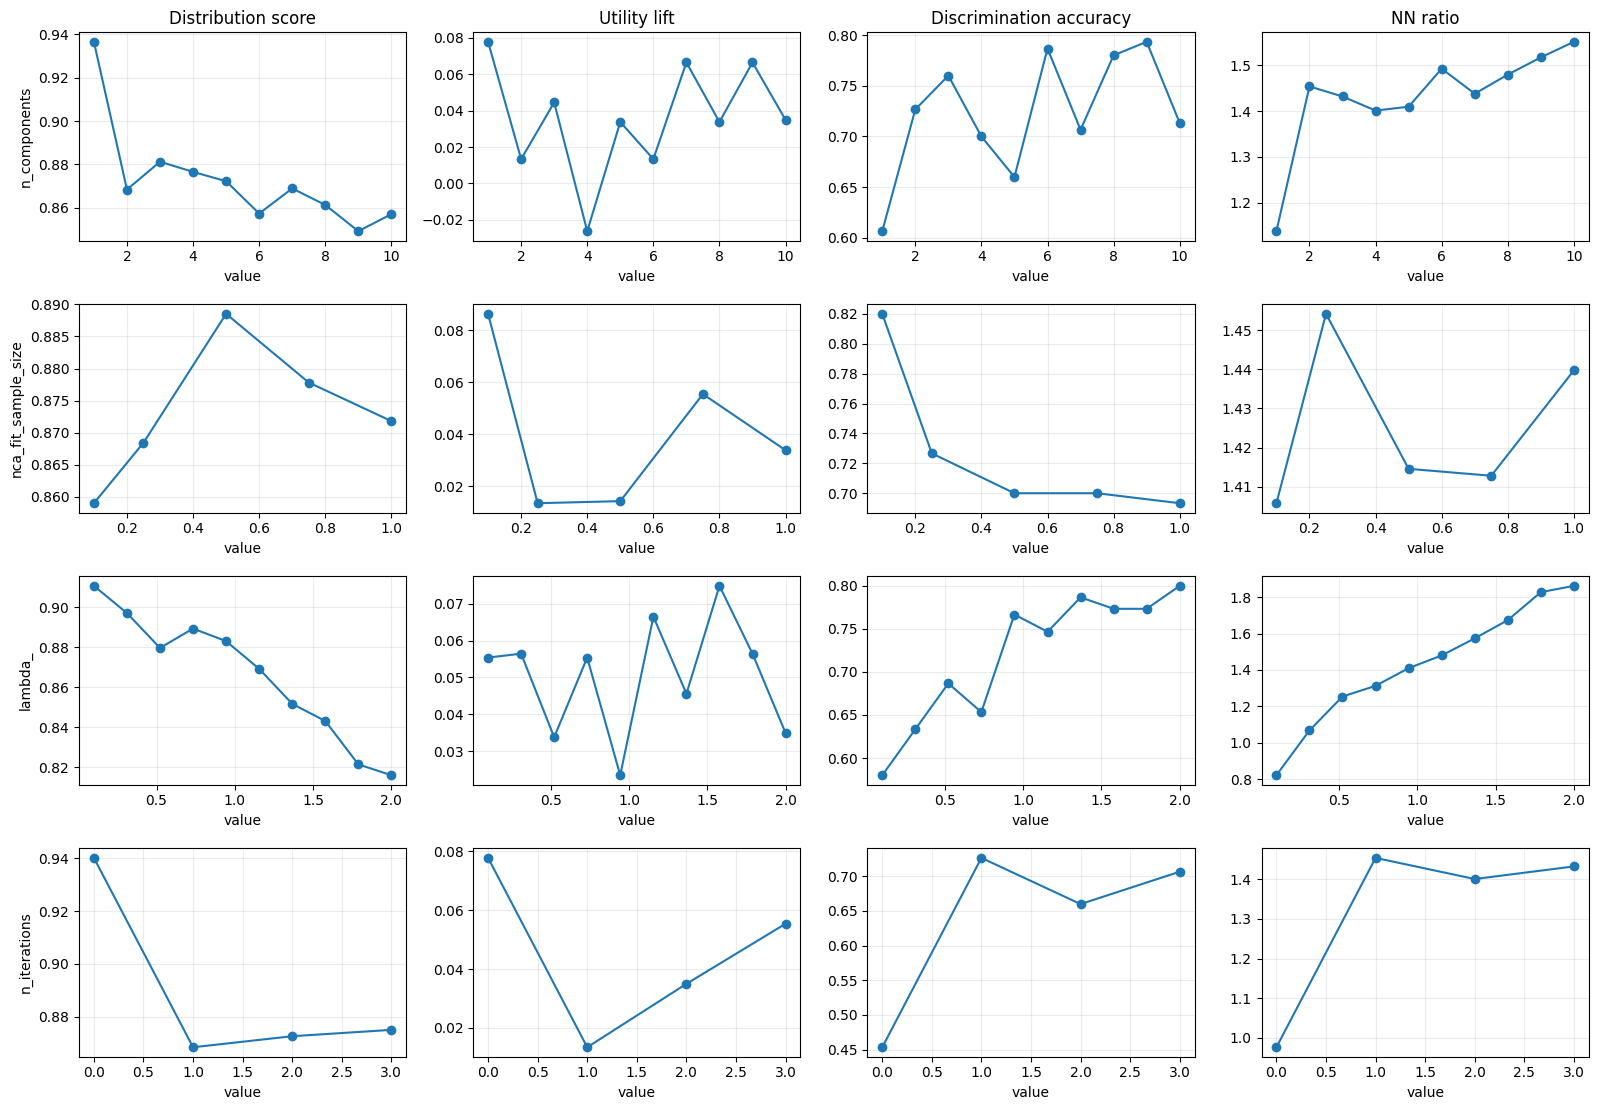

In [6]:
_ = plot_parameter_sensitivity(
    report,
    figures_dir=PATHS.root / "experiments" / "figures",
)